In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import importlib
import astropy.units as u
import matplotlib as mpl

import sys
from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

from config import DATA_PATH
import Plots, TargetData
import Models.HaloModels as HaloModels
import Models.Studies as Studies
import Models.SHMRs as SHMRs

# Plot Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
    'figure.figsize': [9, 6], 'axes.titlesize':30, 'legend.fontsize': 15, 'legend.title_fontsize': 20,
    'axes.labelsize':25, 'xtick.labelsize':15, 'ytick.labelsize':15
})

In [172]:
class test(HaloModels.BaseModel):
    subs = {
        'sample': ['LRG', 'BGS', 'optical'],
        'Lbin': ['L36', 'L48', 'L60', 'L79', 'L98', 'L36D', 'L48D', 'L60D', 'L79D'],
        'mbin': ['M10', 'M1025', 'M105', 'M1075', 'M11', 'M1125'],
        'lambdabin': ['Full', 'L10', 'L20']}
    
    info = {
        'LMin': {'units': 1e10*u.Lsun,
            'LRG': {'L36': 3.58, 'L48': 4.78, 'L60': 5.98, 'L79': 7.86, 'L98': 9.80, 'L36D': 3.58, 'L48D': 4.78, 'L60D': 5.98, 'L79D': 7.86}},
        'LMax': {'units': 1e10*u.Lsun,
            'LRG': {'L36D': 4.78, 'L48D': 5.98, 'L60D': 7.86, 'L79D': 9.80}},
        'MhMin': {'units': 1e13*u.Msun,   # virial mass, 1e13 Msun
            'LRG': {'L36': 0.38, 'L48': 0.63, 'L60': 0.96, 'L79': 1.64, 'L98': 2.59, 'L36D': 0.38, 'L48D': 0.63, 'L60D': 0.96, 'L79D': 1.64}},
        'MhMax': {'units': 1e13*u.Msun,
            'LRG': {'L36D': 0.63, 'L48D': 0.96, 'L60D': 1.64, 'L79D': 2.59}},
        'MsMean': {'units': 1e11*u.Msun,
            'LRG': {'L36': 2.07, 'L48': 2.34, 'L60': 2.70, 'L79': 3.35, 'L98': 4.10, 'L36D': 1.26, 'L48D': 1.61, 'L60D': 2.04, 'L79D': 2.61}},
        'LMean': {'units': 1e10*u.Lsun,
            'LRG': {'L36': 6.89, 'L48': 7.78, 'L60': 9.00, 'L79': 11.18, 'L98': 13.67, 'L36D': 4.21, 'L48D': 5.36, 'L60D': 6.82, 'L79D': 8.71}},
        'zMean': {
            'LRG': {'L36': 0.76, 'L48': 0.78, 'L60': 0.80, 'L79': 0.84, 'L98': 0.88, 'L36D': 0.70, 'L48D': 0.72, 'L60D': 0.76, 'L79D': 0.81},
            'BGS': {'M10': 0.25, 'M1025': 0.27, 'M105': 0.28, 'M1075': 0.30, 'M11': 0.33, 'M1125': 0.36},
            'optical': {'Full': 0.48, 'L10': 0.48, 'L20': 0.47}},
        'N': {
            'LRG': {'L36': 913286, 'L48': 685766, 'L60': 456803, 'L79': 228650, 'L98': 114024, 'L36D': 227520, 'L48D': 228963, 'L60D': 228153, 'L79D': 114626},
            'BGS': {'M10': 1610381, 'M1025': 1379230, 'M105': 1084339, 'M1075': 744562, 'M11': 421150, 'M1125': 178206},
            'optical': {'Full': 220698, 'L10': 80447, 'L20': 22320}},
        'Nf150': {
            'LRG': {'L36': 957095, 'L48': 718542, 'L60': 478585, 'L79': 239567, 'L98': 119353, 'L36D': 238553, 'L48D': 239957, 'L60D': 239018, 'L79D': 120214}},
        'logMsMin': {
            'BGS': {'M10': 10.00, 'M1025': 10.25, 'M105': 10.50, 'M1075': 10.75, 'M11': 11.00, 'M1125': 11.25}},
        'logMsMean': {
            'BGS': {'M10': 10.72, 'M1025': 10.82, 'M105': 10.94, 'M1075': 11.08, 'M11': 11.25, 'M1125': 11.42}},
        'lambdaMin': {
            'optical': {'L10': 10, 'L20': 20}},
        'lambdaMean': {
            'optical': {'Full': 7.04, 'L10': 11.81, 'L20': 20.42}},
        'logMhMean': { 
            # M200m, h^-1 Msun
            'optical': {'Full': 13.45, 'L10': 13.76, 'L20': 14.08}},
        }
    
    def __init__(self, inputsdict={}, **inputvars):
        self.setup(inputsdict | inputvars)
        
    # Given some dictionary of info and an input, if the info is a dict with a key that matches the input, narrow it down to the value of that key. If it's not, return the info as is
    def spefinfo(self, info, input, units):
        # If info is a dict with a key that matches the input, narrow it down to the value of that key. If not, ignore it and move on
        try: info = info[input]
        except: pass
        # If the info is NaN or string, return it as is
        if info is None or isinstance(info, str): return info
        # If info is already a value, return that value with the units
        elif not isinstance(info, dict): return info *units
        # If info is still a dict, rebuild this level of the dict and go down to the next level
        else: return {k: self.spefinfo(v, input, units=units) for k, v in info.items()}
        
    def specify_info(self, infodict, inputdict={}):
        # For every key in the info dict that ISN'T the one that sets units
        for infokey in infodict.keys():  
            # set the value of the key to be the info dict (without the units part)
            setattr(self, infokey, {k: v for k, v in infodict[infokey].items() if k != 'units'})
            # For every input value, which should be a key that matches to one of the info dict keys
            for inp in inputdict.values(): 
                # Try to use that input key to narrow down every value in the info dict
                # NOTE: if an unrelated input has the same name as a spef, it will ALSO narrow this down. maybe fix this           
                spefval = self.spefinfo(getattr(self, infokey), inp, units=infodict[infokey].get('units', u.dimensionless_unscaled))  # try to use it to narrow it down, also applying units if they exist
                setattr(self, infokey, spefval)  # try to use it to narrow it down
                
    def setup(self, inputs, model=False):
        self.check_inputs(inpdict=inputs, optdict=self.subs)  # check inputs
        self.specify_info(self.info, inputdict=inputs)  # narrow down info using inputs
        for inputkey, inputval in inputs.items(): setattr(self, inputkey, inputval)  # set remaining inputs, overriding info
        # self.defineothers()
        self.require = lambda reqlist: self.require_input(inputs, reqlist)

        if model:
            self.check_inputs(inpdict=inputs, optdict=self.models)  # check inputs
            self.p0 = self.specify_info(self.params, inputdict=inputs)  # narrow down info using inputs
            

# Checked

## White 2022

paper ndens: 83.0 1 / deg2, sum of n: 82.32 1 / deg2, 29591
paper ndens: 149.0 1 / deg2, sum of n: 147.13 1 / deg2, 52884
paper ndens: 162.0 1 / deg2, sum of n: 159.91 1 / deg2, 57472
paper ndens: 149.0 1 / deg2, sum of n: 146.63 1 / deg2, 52727


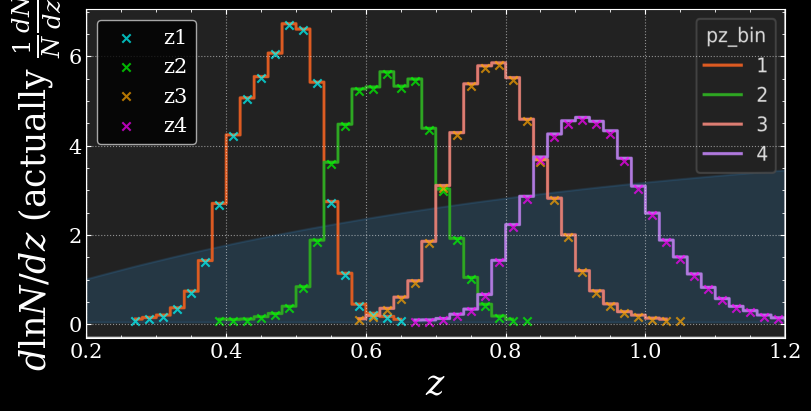

In [2]:
importlib.reload(Plots); importlib.reload(TargetData); importlib.reload(Studies)
fig, ax = Plots.White2022().Fig2()

for zbin, color in zip(['z1', 'z2', 'z3', 'z4'], ['cyan', 'lime', 'orange', 'magenta']):
    W22 = TargetData.White2022(zbin=zbin)
    W22.make_zdists(dz=0.02)
    ax.scatter(W22.z, W22.dndz/W22.ndens, c=color, marker='x', alpha=0.7, label=zbin)
    
    print(f'paper ndens: {W22.ndens}, sum of n: {np.sum(W22.n_z):.2f}, {np.trapezoid(W22.N_z, W22.z):.0f}')

ax.legend(loc='upper left')
plt.show()

## Kusiak 2022

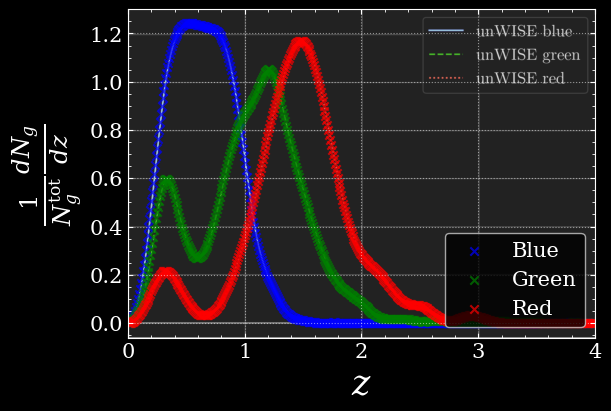

In [3]:
importlib.reload(Plots); importlib.reload(Studies); importlib.reload(TargetData)
fig, ax = Plots.Kusiak2022().Fig2()

for subsamp, color in zip(['Blue', 'Green', 'Red'], ['b', 'g', 'r']):
    K22 = TargetData.Kusiak2022({'sample':subsamp})
    K22.make_zdists()
    ax.scatter(K22.z, K22.dNdz_norm, c=color, marker='x', alpha=0.7, label=subsamp)

ax.legend(loc='lower right')
plt.show()

## Liu 2025

z1 paper ndens=81.9 1 / deg2, sum of n 82.01 1 / deg2, int of dndz 82.01 1 / deg2
z2 paper ndens=148.1 1 / deg2, sum of n 148.18 1 / deg2, int of dndz 148.18 1 / deg2
z3 paper ndens=162.4 1 / deg2, sum of n 162.52 1 / deg2, int of dndz 162.52 1 / deg2
z4 paper ndens=148.3 1 / deg2, sum of n 148.50 1 / deg2, int of dndz 148.50 1 / deg2


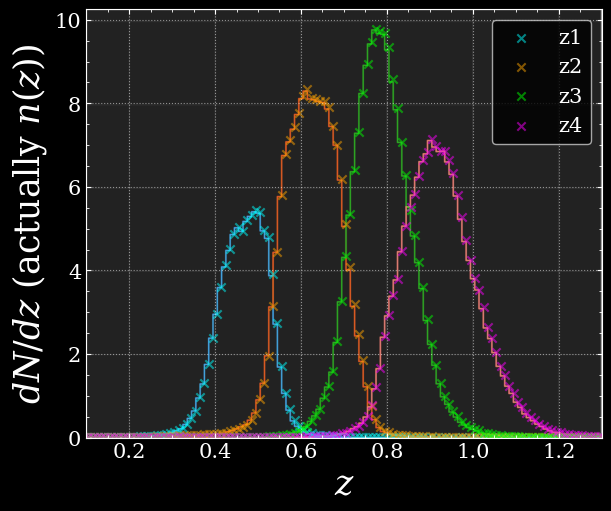

In [4]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, ax = Plots.Liu2025().Fig2()

for zbin, color in zip(['z1', 'z2', 'z3', 'z4'], ['cyan', 'orange', 'lime', 'magenta']):
    L25 = TargetData.Liu2025(zbin=zbin)
    L25.make_zdist()
    print(f'{L25.zbin} paper ndens={L25.nGal}, sum of n {np.sum(L25.n_z):.2f}, int of dndz {np.trapezoid(L25.dndz, L25.z):.2f}')
    ax.scatter(L25.z, L25.n_z, alpha=0.5, marker='x', c=color, label=f'{L25.zbin}')

ax.legend()
plt.show()

## Ried-Guachalla 2025

z_1 Ngal=195877 from paper, sum of N_z 195951, int of dNdz 178007
z_2 Ngal=235620 from paper, sum of N_z 297541, int of dNdz 268667
z_3 Ngal=235620 from paper, sum of N_z 235710, int of dNdz 207202
z_4 Ngal=96346 from paper, sum of N_z 96378, int of dNdz 86654


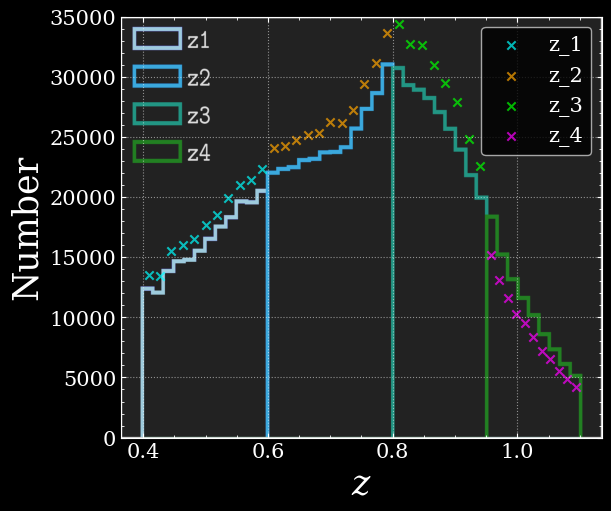

In [2]:
importlib.reload(Plots); importlib.reload(TargetData); importlib.reload(Studies)
fig, ax = Plots.RiedGuachalla2025().Fig2()

bins = ['z_1', 'z_2', 'z_3', 'z_4']
colors = ['cyan', 'orange', 'lime', 'magenta']
zNums = [12, 12, 9, 12]
for bin, color, zNum in zip(bins, colors, zNums):
    RG25 = TargetData.RiedGuachalla2025(bin=bin)
    RG25.make_zdist(zNum=zNum)
    ax.scatter(RG25.z, RG25.N_z, alpha=0.7, marker='x', c=color, label=f'{RG25.bin}')
    
    print(f"{RG25.bin} Ngal={RG25.NGal} from paper, sum of N_z {RG25.N_z.sum():.0f}, int of dNdz {np.trapezoid(RG25.dNdz, RG25.z):.0f}")

ax.legend()
plt.show()

In [3]:
RG25.make_Mhdist(logMhNum=12, halomodel=HaloModels.astropy_model())

mass_1 Ngal=244932, sum of N_logMs 244932, int of dNdlogMs 209903
mass_2 Ngal=320914, sum of N_logMs 320914, int of dNdlogMs 215228
mass_3 Ngal=194037, sum of N_logMs 194037, int of dNdlogMs 128429
mass_4 Ngal=53997, sum of N_logMs 53997, int of dNdlogMs 43524


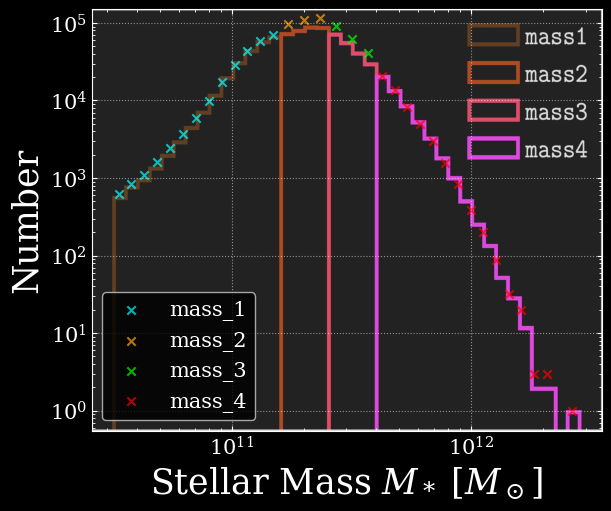

In [4]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, ax = Plots.RiedGuachalla2025().Fig3()

bins = ['mass_1', 'mass_2', 'mass_3', 'mass_4']
colors = ['cyan', 'orange', 'lime', 'red']
logMsNums = [14, 4, 4, 18]
for bin, color, logMsNum in zip(bins, colors, logMsNums):
    RG25 = TargetData.RiedGuachalla2025(bin=bin)
    RG25.make_Msdist(logMsNum=logMsNum, halomodel=HaloModels.astropy_model())
    ax.scatter(10**RG25.logMs, RG25.N_logMs, alpha=0.7, marker='x', c=color, label=f'{RG25.bin}')
    
    print(f'{RG25.bin} Ngal={RG25.NGal}, sum of N_logMs {RG25.N_logMs.sum():.0f}, int of dNdlogMs {np.trapezoid(RG25.N_logMs/RG25.dlogMs, RG25.logMs):.0f}')

ax.legend(loc='lower left')
plt.show()

## Gao 2023

AttributeError: 'Gao2023' object has no attribute 'make_zdists'

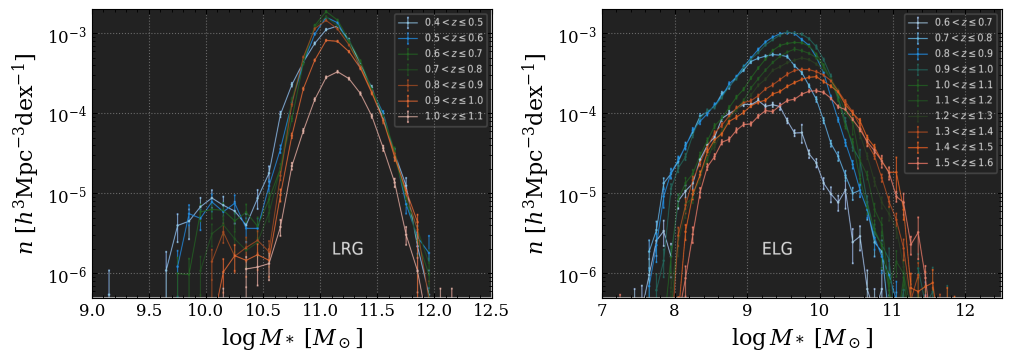

In [81]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, axs = Plots.Gao2023().Fig2()

G23= TargetData.Gao2023(sample='LRG')
G23.make_zMsdists()
for i, z in enumerate(G23.z):
    axs[0].scatter(G23.logMs, G23.n_logMs_z_h3[i], alpha=0.7, marker='x', label=f'z={z:.2f}')

G23 = TargetData.Gao2023(sample='ELG')
G23.make_zMsdists()
for i, z in enumerate(G23.z):
    axs[1].scatter(G23.logMs, G23.n_logMs_z_h3[i], alpha=0.7, marker='x', label=f'z={z:.2f}')

axs[0].legend(fontsize=10, loc='upper left'); axs[1].legend(fontsize=10, loc='upper left')
plt.show()

In [14]:
G23= TargetData.Gao2023(sample='LRG')
G23.make_zMsdists()
mcut = (G23.logMs_df>=11.1) & (G23.logMs_df<=11.9)
zcut = (G23.z_df>=0.8) & (G23.z_df<=1.0)
N_z_logMs = G23.dNdzdlogMs_df*(G23.z_df[1]-G23.z_df[0])*(G23.logMs_df[1]-G23.logMs_df[0]) * u.dex
print(G23.z_df[zcut], G23.logMs_df[mcut])
N = 13906+4834+957+124
print(np.sum(N_z_logMs[:,mcut][zcut], axis=0).reshape(-1, 2).sum(axis=1))
print(f'{N:.3e}', f'{np.sum(N_z_logMs[:,mcut][zcut]):.3e}')

[0.85 0.95] [11.15 11.25 11.35 11.45 11.55 11.65 11.75 11.85]
[13820.64802317  4819.76390403   958.53731266   125.9293599 ]
1.982e+04 1.972e+04


In [15]:
G23= TargetData.Gao2023(sample='LRG')
G23.make_zMsdists(dlogMs=0.001, dz=0.01)
mcut = (G23.logMs>=11.1) & (G23.logMs<=11.9)
zcut = (G23.z>=0.8) & (G23.z<=1.0)
N = 13906+4834+957+124
print(f'{N:.3e}', f'{np.sum(G23.N_z_logMs[:,mcut][zcut]):.3e}')
print(f'{np.trapezoid(G23.dNdz, G23.z*u.dex):.3e}', f'{np.sum(G23.N_z_logMs):.3e}')

G23= TargetData.Gao2023(sample='ELG')
G23.make_zMsdists(dlogMs=0.001, dz=0.01)
mcut = (G23.logMs>=8.5) & (G23.logMs<=10.5)
zcut = (G23.z>=0.8) & (G23.z<=1.0)
N=9481+29764+34155+6583
print(f'{N:.3e}', f'{np.sum(G23.N_z_logMs[:,mcut][zcut]):.3e}')
print(f'{np.trapezoid(G23.dNdz, G23.z*u.dex):.3e}', f'{np.sum(G23.N_z_logMs):.3e}')

1.982e+04 1.941e+04
1.040e+05 1.045e+05
7.998e+04 8.185e+04
2.523e+05 2.525e+05


# All

/tmp/ipykernel_1253671/1473466980.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(zave, np.interp(zave,mod.z, mod.dNdz), c=cmap(norm(zave)), marker='v', s=100, alpha=0.5)
/tmp/ipykernel_1253671/1473466980.py:34: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(zave, np.interp(zave,mod.z, mod.dNdz), c=cmap(norm(zave)), marker='v', s=100, alpha=0.5)


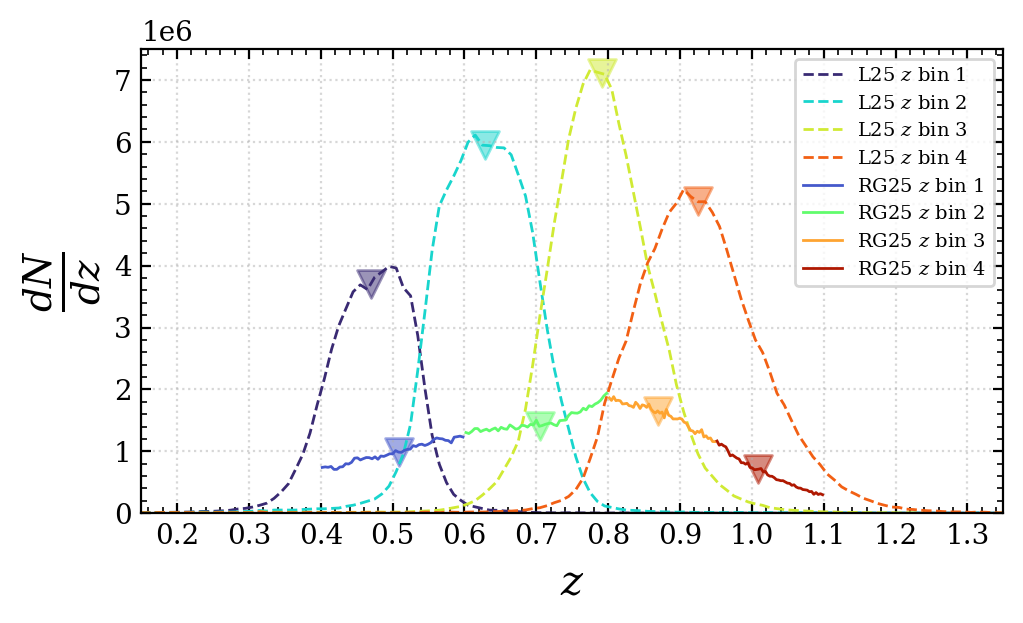

In [9]:
importlib.reload(Studies); importlib.reload(TargetData)

plt.style.use('default')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
})

fig, ax = plt.subplots(1, 1, figsize=(5, 3), layout='constrained', dpi=200)

RG25 = [TargetData.RiedGuachalla2025(bin=bin) for bin in ['z_1', 'z_2', 'z_3', 'z_4']]
L25 = [TargetData.Liu2025(zbin=bin) for bin in ['z1', 'z2', 'z3', 'z4']]


norm = mpl.colors.Normalize(vmin=0.45, vmax=1.05)
cmap = plt.get_cmap('turbo')

for zbin,mod in enumerate(L25):
    mod.make_zdist(zNum=100)
    zave = mod.distave(mod.z, mod.dNdz)
    # print(f"{mod.__class__.__name__}: {zave:.2f}")
    # ax.axvline(zave, c=cmap(norm(zave)), lw=1, alpha=0.5, ls='--')
    ax.plot(mod.z, mod.dNdz, label=rf"L25 $z$ bin {zbin+1}", c=cmap(norm(zave)), ls='--', lw=1)
    ax.scatter(zave, np.interp(zave,mod.z, mod.dNdz), c=cmap(norm(zave)), marker='v', s=100, alpha=0.5)
    
colors = ['orangered', 'orange', 'springgreen','blue']
for zbin, mod in enumerate(RG25):
    mod.make_zdist(zNum=50)
    zave = mod.distave(mod.z, mod.dNdz)
    # print(f"{mod.__class__.__name__}: {zave:.2f}")
    ax.plot(mod.z, mod.dNdz, label=rf"RG25 $z$ bin {zbin+1}", c=cmap(norm(zave)), lw=1)
    ax.scatter(zave, np.interp(zave,mod.z, mod.dNdz), c=cmap(norm(zave)), marker='v', s=100, alpha=0.5)


ax.legend(fontsize=7)
ax.set_xticks(np.arange(0.2, 1.4, 0.1))
ax.set_yticks(np.arange(0, 8e6, 1e6))
ax.set(xlim=(0.15, 1.35), ylim=(0, 7.5e6))
ax.set_xlabel(r'$z$', fontsize=15)
ax.set_ylabel(r'$\frac{dN}{dz}$', fontsize=20)
# ax.grid(True, linestyle=':', alpha=0.9, lw=0.5)
plt.show()

/tmp/ipykernel_1253671/3211669101.py:29: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(logMave, np.interp(logMave,mod.logMs, mod.dNdlogMs), c=cmap(norm(logMave)), marker='v', s=100, alpha=0.5)


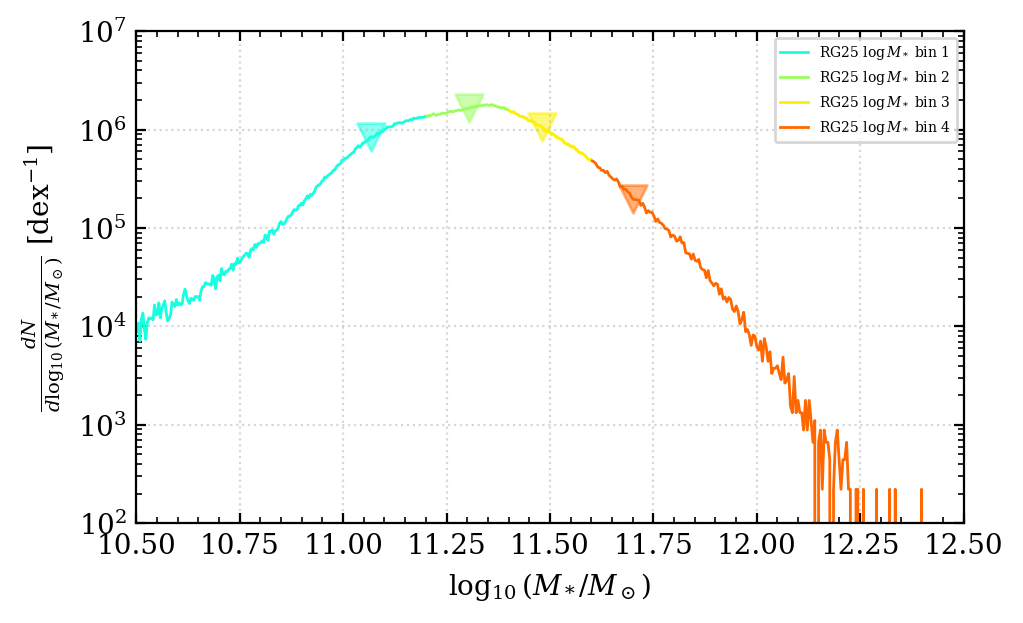

In [84]:
importlib.reload(Studies); importlib.reload(TargetData)

plt.style.use('default')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
})

fig, ax = plt.subplots(1, 1, figsize=(5, 3), layout='constrained', dpi=200)

RG25 = [TargetData.RiedGuachalla2025(bin=bin) for bin in ['mass_1', 'mass_2', 'mass_3', 'mass_4']]
hmod = HaloModels.astropy_model()
norm = mpl.colors.Normalize(vmin=10.5, vmax=12)
cmap = plt.get_cmap('jet')

for mbin, mod in enumerate(RG25):
    # mod.make_Msdist(dlogMs=0.1, logMsMin=9, logMsMax=15, halomodel=hmod)
    if mbin==0: logMsNum=200
    elif mbin==1: logMsNum=50
    elif mbin==2: logMsNum=75
    elif mbin==3: logMsNum=200
    
    mod.make_Msdist(logMsNum=logMsNum, halomodel=hmod)
    logMave = mod.distave(mod.logMs, mod.dNdlogMs)
    # print(f"{mod.__class__.__name__}: {zave:.2f}")
    ax.plot(mod.logMs, mod.dNdlogMs, label=rf"RG25 $\log M_*$ bin {mbin+1}", c=cmap(norm(logMave)), lw=1)
    ax.scatter(logMave, np.interp(logMave,mod.logMs, mod.dNdlogMs), c=cmap(norm(logMave)), marker='v', s=100, alpha=0.5)


ax.set(ylabel=r'$\frac{dN}{d\log_{10}(M_*/M_\odot)} \ [\text{dex}^{-1}]$')
ax.set(xlabel=r'$\log_{10}(M_*/M_\odot)$')
ax.set(xlim=(10.5, 12.5), ylim=(1e2, 1e7), yscale='log')
ax.legend(fontsize=5)
plt.show()

Liu2025: 0.72


AttributeError: 'list' object has no attribute 'make_zdist'

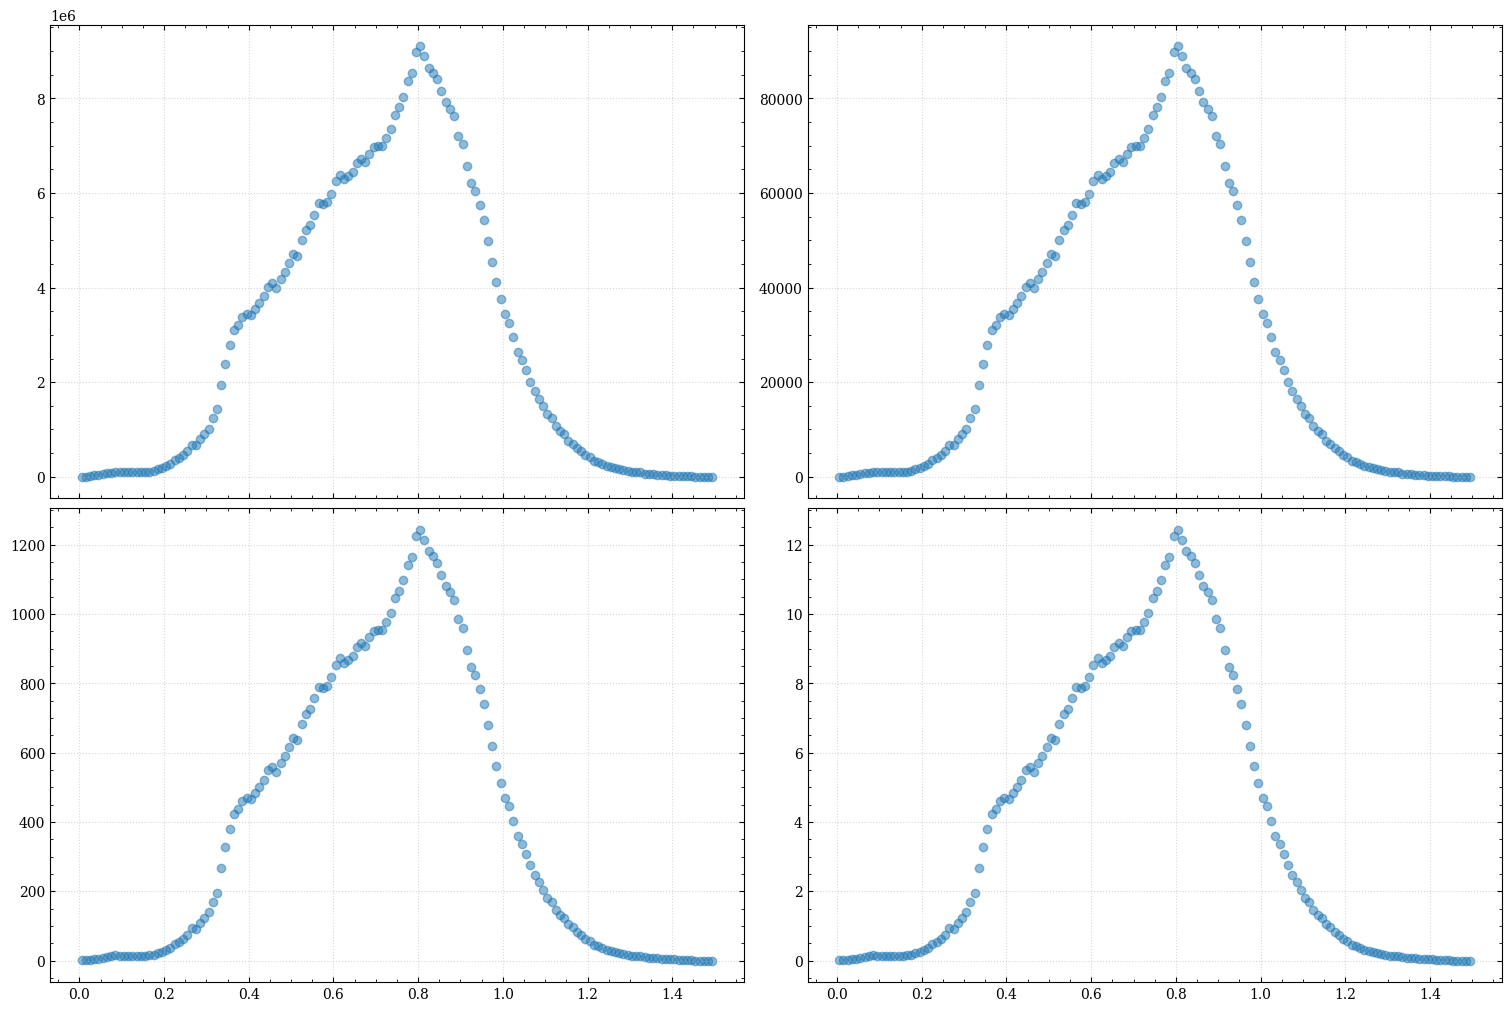

In [52]:
importlib.reload(Studies); importlib.reload(TargetData)

fig, axs = plt.subplots(2, 2, figsize=(15, 10), layout='constrained', sharex='col')
axs=axs.flatten()

W22 = TargetData.White2022(zbin='z1')
L25 = TargetData.Liu2025(zbin='all')

K22 = TargetData.Kusiak2022(sample='Blue')

for mod in [L25, RG25]:
    mod.make_zdist()
    print(f"{mod.__class__.__name__}: {mod.distave(mod.z, mod.dNdz):.2f}")
    axs[0].scatter(mod.z, mod.dNdz, alpha=0.5, label=mod.__class__.__name__)
    axs[1].scatter(mod.z, mod.N_z, alpha=0.5, label=mod.__class__.__name__)
    axs[2].scatter(mod.z, mod.dndz, alpha=0.5, label=mod.__class__.__name__)
    axs[3].scatter(mod.z, mod.n_z, alpha=0.5, label=mod.__class__.__name__)

for ax in axs: ax.set(xlim=(0, 2))

axs[0].set(ylabel=r'$\frac{dN}{dz} \ []$'); axs[0].legend()
axs[1].set(ylabel=r'$N \ []$'); axs[1].legend()
axs[2].set(xlabel=r'$z$', ylabel=r'$\frac{dn}{dz} \ [\text{deg}^{-2}]$'); axs[2].legend()
axs[3].set(xlabel=r'$z$', ylabel=r'$n \ [\text{deg}^{-2}]$'); axs[3].legend()
plt.show()

10.500010494186252 12.400149347166398


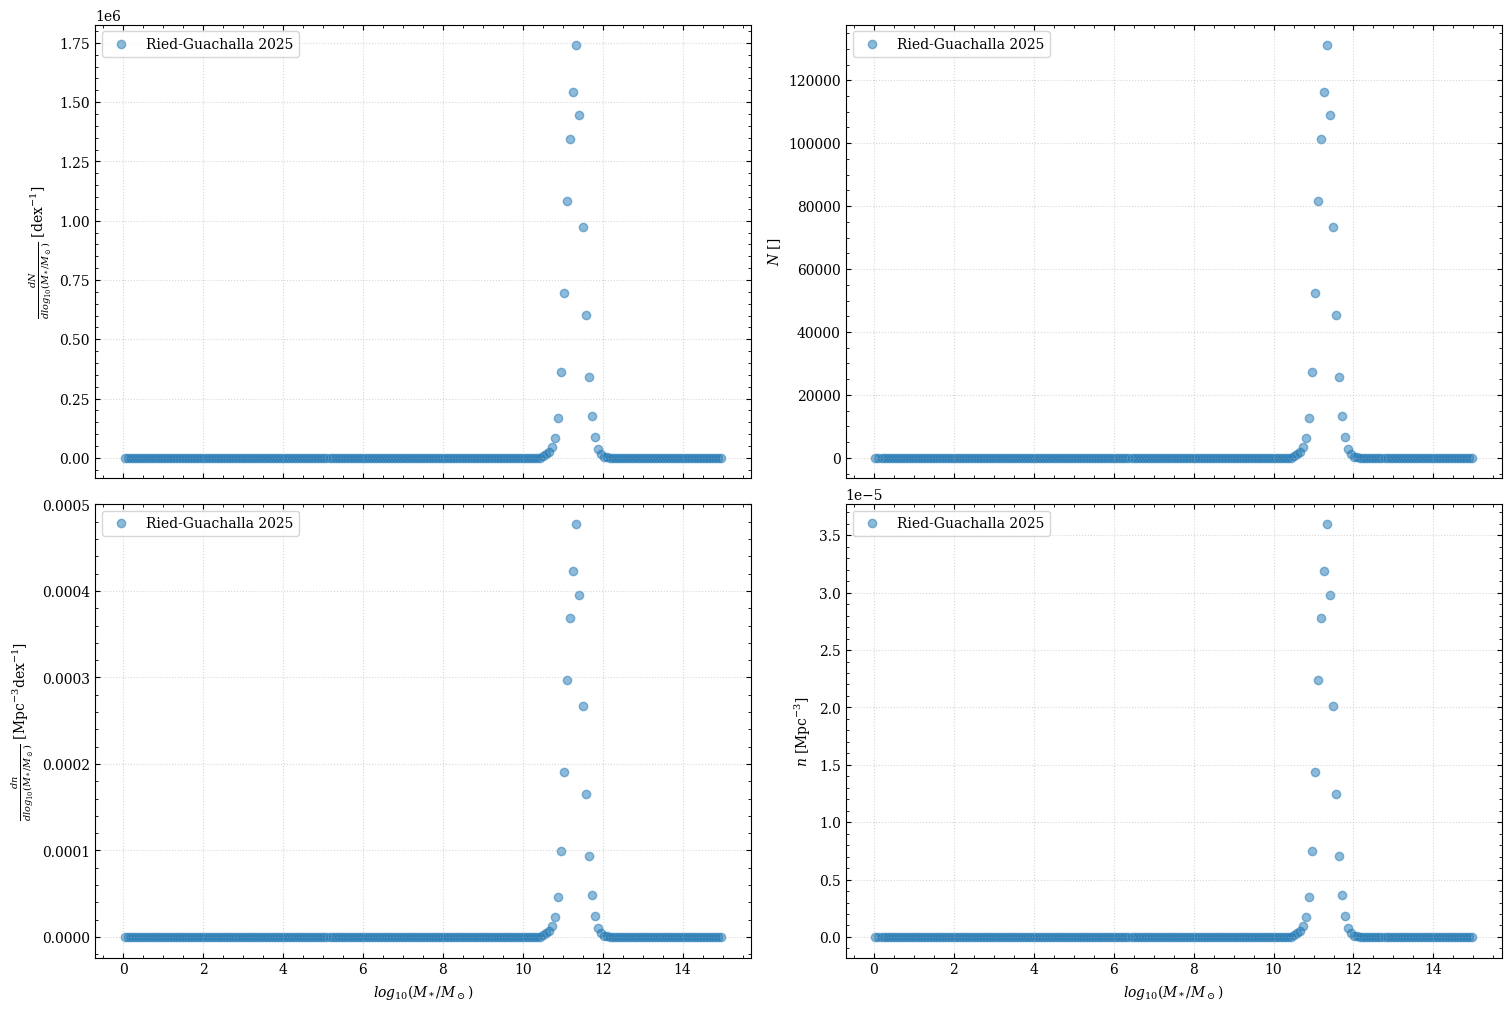

In [53]:
importlib.reload(Studies); importlib.reload(TargetData)

fig, axs = plt.subplots(2, 2, figsize=(15, 10), layout='constrained', sharex='col')
axs=axs.flatten()

hmod = HaloModels.astropy_model()

# L25 = TargetData.Liu2025(zbin='all')
RG25 = TargetData.RiedGuachalla2025(bin='all')

for mod, name in zip([RG25], ['Ried-Guachalla 2025']):
    mod.make_Msdist(logMsNum=200, halomodel=hmod)
    axs[0].scatter(mod.logMs, mod.dNdlogMs, alpha=0.5, label=name)
    axs[1].scatter(mod.logMs, mod.N_logMs, alpha=0.5, label=name)
    axs[2].scatter(mod.logMs, mod.dndlogMs, alpha=0.5, label=name)
    axs[3].scatter(mod.logMs, mod.n_logMs, alpha=0.5, label=name)

axs[0].set(ylabel=r'$\frac{dN}{dlog_{10}(M_*/M_\odot)} \ [\text{dex}^{-1}]$'); axs[0].legend()
axs[1].set(ylabel=r'$N \ []$'); axs[1].legend()
axs[2].set(xlabel=r'$log_{10}(M_*/M_\odot)$', ylabel=r'$\frac{dn}{dlog_{10}(M_*/M_\odot)} \ [\text{Mpc}^{-3} \text{dex}^{-1}]$'); axs[2].legend()
axs[3].set(xlabel=r'$log_{10}(M_*/M_\odot)$', ylabel=r'$n \ [\text{Mpc}^{-3}]$'); axs[3].legend()
plt.show()

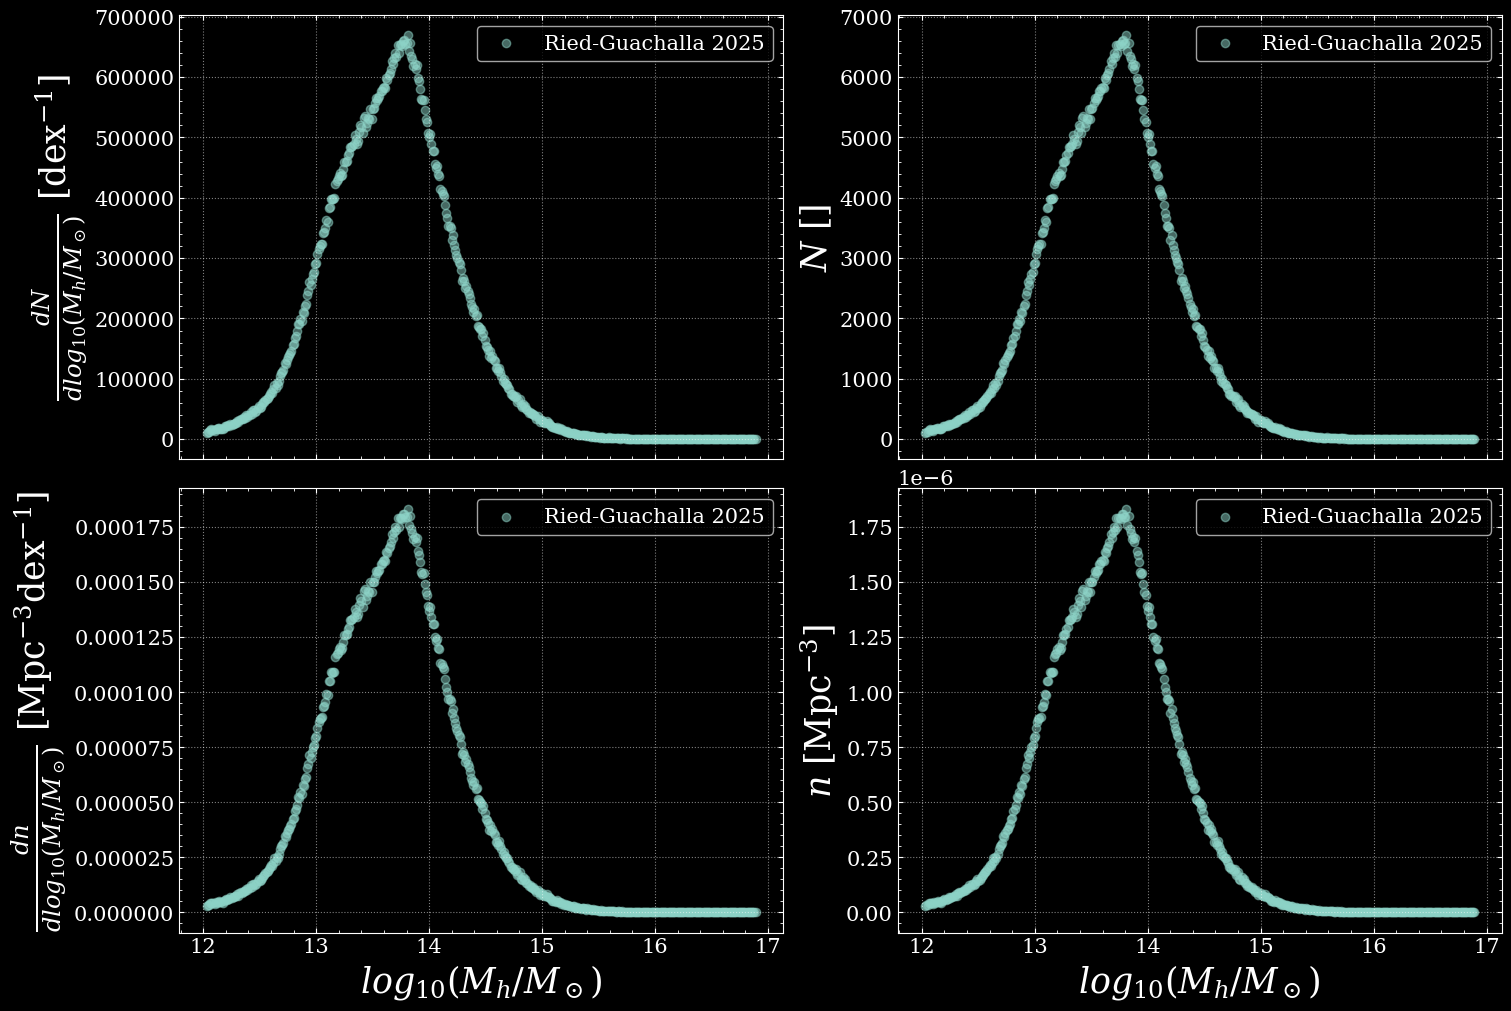

In [18]:
importlib.reload(Studies); importlib.reload(TargetData)

fig, axs = plt.subplots(2, 2, figsize=(15, 10), layout='constrained', sharex='col')
axs=axs.flatten()

hmod = HaloModels.astropy_model()

# L25 = TargetData.Liu2025(zbin='all')
RG25 = TargetData.RiedGuachalla2025(bin='all')

for mod, name in zip([RG25], ['Ried-Guachalla 2025']):
    mod.make_Mdists(halomodel=hmod)
    axs[0].scatter(mod.logM, mod.dNdlogM, alpha=0.5, label=name)
    axs[1].scatter(mod.logM, mod.N_logM, alpha=0.5, label=name)
    axs[2].scatter(mod.logM, mod.dndlogM, alpha=0.5, label=name)
    axs[3].scatter(mod.logM, mod.n_logM, alpha=0.5, label=name)

axs[0].set(ylabel=r'$\frac{dN}{dlog_{10}(M_h/M_\odot)} \ [\text{dex}^{-1}]$'); axs[0].legend()
axs[1].set(ylabel=r'$N \ []$'); axs[1].legend()
axs[2].set(xlabel=r'$log_{10}(M_h/M_\odot)$', ylabel=r'$\frac{dn}{dlog_{10}(M_h/M_\odot)} \ [\text{Mpc}^{-3} \text{dex}^{-1}]$'); axs[2].legend()
axs[3].set(xlabel=r'$log_{10}(M_h/M_\odot)$', ylabel=r'$n \ [\text{Mpc}^{-3}]$'); axs[3].legend()
plt.show()

# Unchecked

## Hadzhiyska 2026

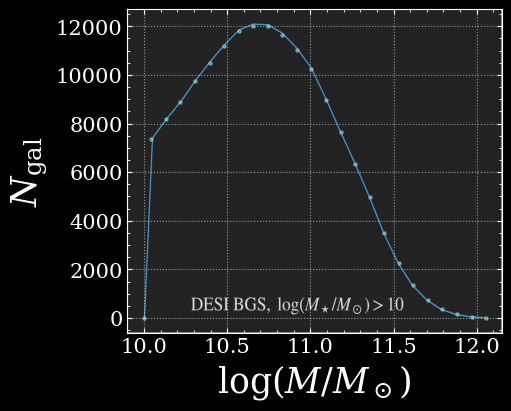

In [3]:
importlib.reload(Plots); importlib.reload(Studies); importlib.reload(TargetData)
fig, ax = Plots.Hadzhiyska2026().Fig2a()

H26 = TargetData.Hadzhiyska2026()
H26.make_Msdist(halomodel=HaloModels.astropy_model(), logMsNum=25, logMsMax=12.1)

ax.scatter(np.concatenate([[10],H26.logMs]), np.concatenate([[0],H26.N_logMs/10]), alpha=0.6, s=5)
# ax.scatter(H26.logMs, H26.N_logMs/10, alpha=0.6, s=5)

plt.show()

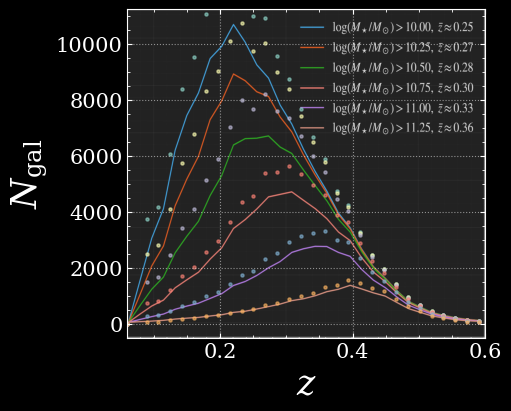

In [180]:
importlib.reload(Plots); importlib.reload(Studies); importlib.reload(TargetData)
fig, ax = Plots.Hadzhiyska2026().Fig2b()

logMsMins = [10, 10.25, 10.50, 10.75, 11, 11.25]
colors = ['b', 'green', 'r', 'y', 'cyan', 'magenta']
for logMsMin, color in zip(logMsMins, colors):
    H26 = TargetData.Hadzhiyska2026()
    H26.make_zdist(zNum=30, logMsMin=logMsMin, zMax=0.6)
    ax.scatter(np.concatenate([[0.06], H26.z]), np.concatenate([[0],H26.N_z/10]), alpha=0.6, s=5)

plt.show()

## Moore 2026

In [18]:
importlib.reload(Plots); importlib.reload(TargetData); importlib.reload(SHMRs); importlib.reload(Studies)



M26_j = TargetData.Moore2026(sample='LRG', masstype='Mvir', bin='L36')

In [25]:
M26_j

In [13]:
np.sum(M26_j.dfdata['valid_radio_2.1']==1)

949284

In [12]:
np.sum(M26_j.dfdata['valid_radio_2.1']==0)

248063

LRG Paper N: 913286.0, sum N_z 1197347, int dNdz 1197210
LRG Paper zMean: 0.76, data 0.72
LRG Paper N: 913286.0, sum N_logMs 1197347, int dNdlogMs 1197326
LRG Paper logMsMean: 11.32, data 11.18
LRG Paper N: 913286.0, sum N_logMh 958282, int dNdlogMh 883021
LRG Paper logMhMean: None, data 13.08
BGS Paper N: 1610381.0, sum N_z 1610381, int dNdz 1597075
BGS Paper zMean: 0.25, data 0.26
BGS Paper N: 1610381.0, sum N_logMs 1610381, int dNdlogMs 1586208
BGS Paper logMsMean: 10.72, data 10.73
BGS Paper N: 1610381.0, sum N_logMh 1610381, int dNdlogMh 1526703
BGS Paper logMhMean: None, data 12.35
optical Paper N: 220698.0, sum N_z 220698, int dNdz 220334
optical Paper zMean: 0.48, data 0.48
optical Paper N: 220698.0, sum N_logMh 220698, int dNdlogMh 209288
optical Paper logMhMean: 13.45, data 13.75


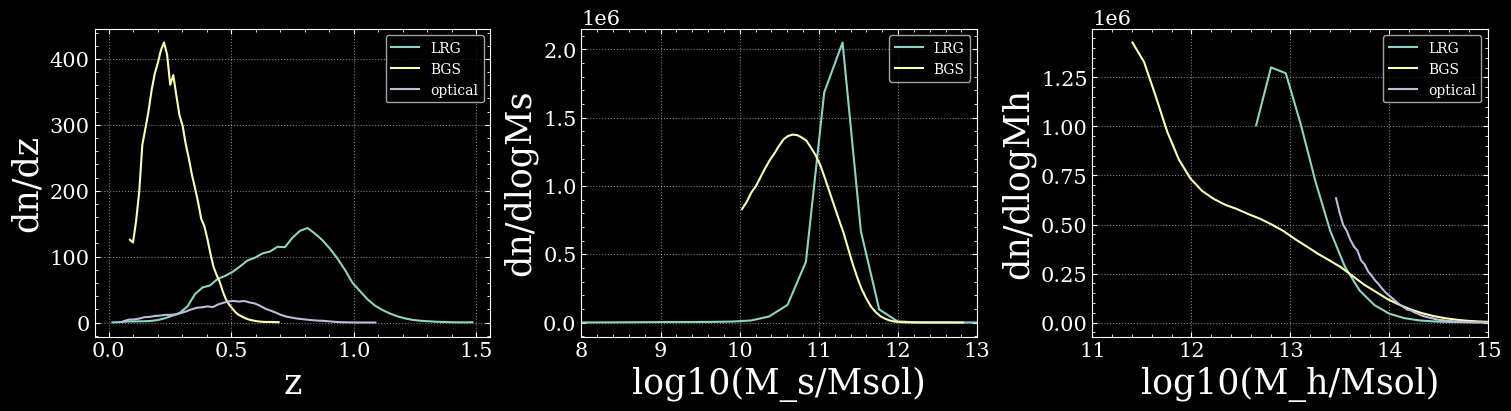

In [ ]:
importlib.reload(Plots); importlib.reload(TargetData); importlib.reload(SHMRs); importlib.reload(Studies)

fig, axs = plt.subplots(1, 3, figsize=(15, 4), layout='constrained')

M26_j = TargetData.Moore2026(sample='LRG', masstype='Mvir', bin='L36')
M26_b = TargetData.Moore2026(sample='BGS', bin='M10')
M26_o = TargetData.Moore2026(sample='optical', bin='Full')

for mod in [M26_j, M26_b, M26_o]:
    mod.make_zdist(zNum=50)
    axs[0].plot(mod.z, mod.dndz, label=mod.sample)
    print(f"{mod.sample} Paper N: {mod.N}, sum N_z {np.sum(mod.N_z):.0f}, int dNdz {np.trapezoid(mod.dNdz, mod.z):.0f}")
    print(f"{mod.sample} Paper zMean: {mod.zMean}, data {mod.distave(mod.z, mod.dNdz):.2f}")

    if mod!=M26_o:
        mod.make_Msdist(logMsNum=50, halomodel=HaloModels.astropy_model())
        axs[1].plot(mod.logMs, mod.dNdlogMs, label=mod.sample)
        print(f"{mod.sample} Paper N: {mod.N}, sum N_logMs {np.sum(mod.N_logMs):.0f}, int dNdlogMs {np.trapezoid(mod.dNdlogMs, mod.logMs):.0f}")
        print(f"{mod.sample} Paper logMsMean: {mod.logMsMean:.2f}, data {mod.distave(mod.logMs, mod.dNdlogMs):.2f}")

    mod.make_Mhdist(logMhNum=50, halomodel=HaloModels.astropy_model())
    axs[2].plot(mod.logMh, mod.dNdlogMh, label=mod.sample)
    print(f"{mod.sample} Paper N: {mod.N}, sum N_logMh {np.sum(mod.N_logMh):.0f}, int dNdlogMh {np.trapezoid(mod.dNdlogMh, mod.logMh):.0f}")
    print(f"{mod.sample} Paper logMhMean: {mod.logMhMean}, data {mod.distave(mod.logMh, mod.dNdlogMh):.2f}")

axs[0].set(xlabel='z', ylabel='dn/dz')
axs[1].set(xlabel='log10(M_s/Msol)', ylabel='dn/dlogMs'); axs[1].set(xlim=(8, 13))
axs[2].set(xlabel='log10(M_h/Msol)', ylabel='dn/dlogMh'); axs[2].set(xlim=(11, 15))
axs[0].legend(fontsize=10); axs[1].legend(fontsize=10); axs[2].legend(fontsize=10)
plt.show()

In [ ]:
import pandas as pd

dfdata = pd.read_csv(f"{DATA_PATH}/Moore2026/iskay_RM_ls10_iron_v1_CGz_cat_310525.csv")

z_df = dfdata['z']
richness_df = dfdata['lum']

import SHMRs
masses_df = SHMRs.To2020(h=0.7).SRMR(richness_df)()

In [36]:
np.log(5e14)

33.84562921435074

$\log M_{200m} = 14.351 (\lambda /40)^{1.058}$

(array([9.1428e+04, 5.8461e+04, 3.5008e+04, 1.9581e+04, 9.7490e+03,
        4.2320e+03, 1.5810e+03, 4.9700e+02, 1.4400e+02, 1.7000e+01]),
 array([13.443284  , 13.61964559, 13.79600718, 13.97236878, 14.14873037,
        14.32509196, 14.50145355, 14.67781515, 14.85417674, 15.03053833,
        15.20689992]),
 <BarContainer object of 10 artists>)

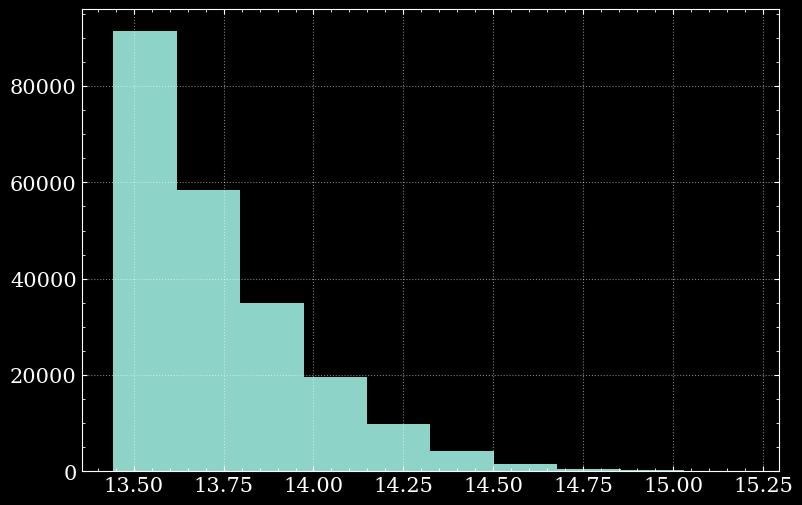

In [35]:
plt.hist(np.log10(masses_df))

## Zhou 2023

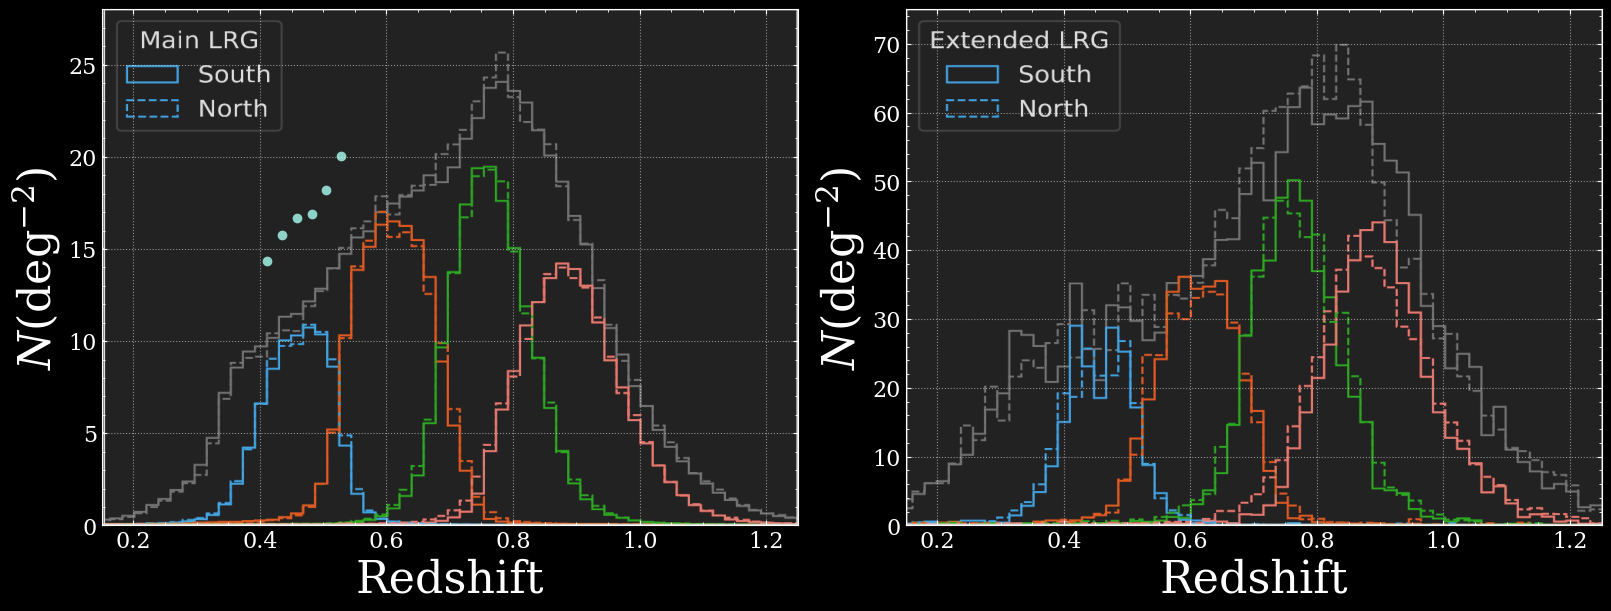

In [216]:
importlib.reload(Plots); importlib.reload(TargetData); importlib.reload(Studies)
fig, axs = Plots.Zhou2023().Fig2()

Z23 = TargetData.Zhou2023(zbin='z1', sample='main', hemisphere='combined')
Z23.make_zdist(dz=0.02)

axs[0].scatter(Z23.z, Z23.n_z)

plt.show()

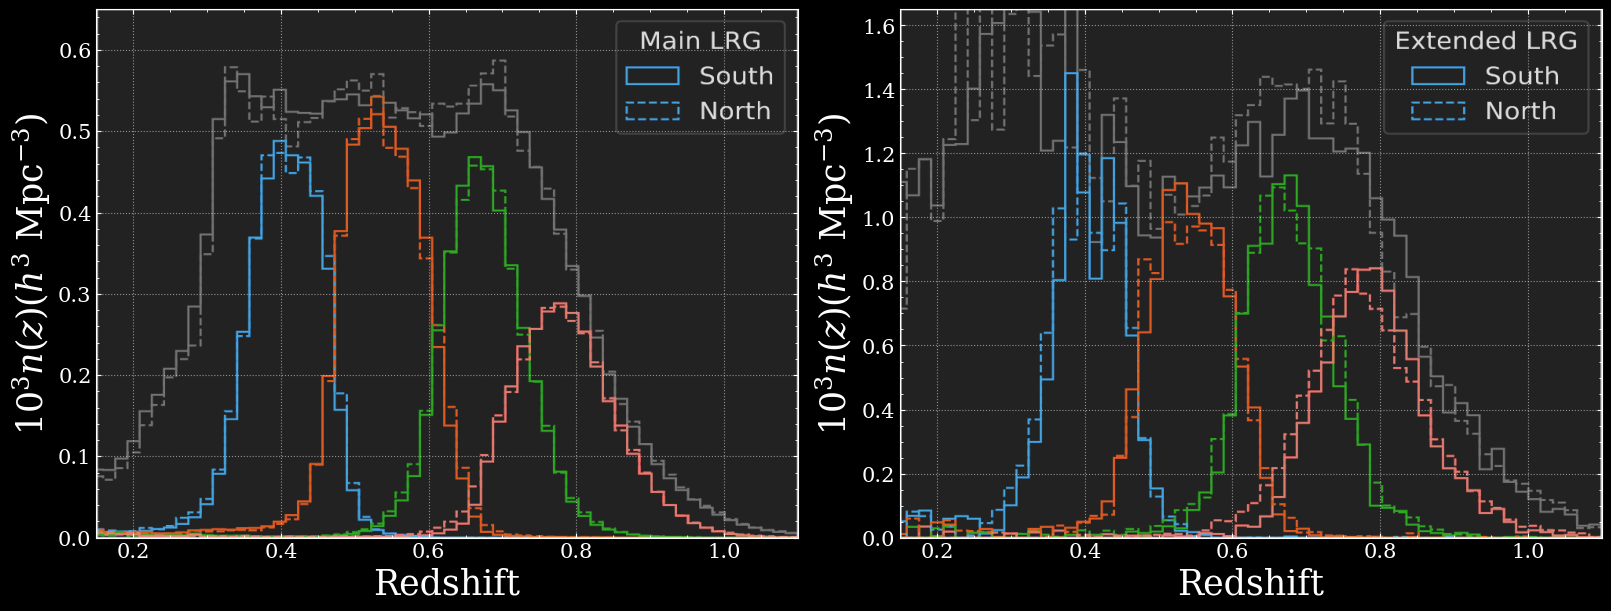

In [101]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, ax = Plots.Zhou2023().Fig3()

## Moser 2021

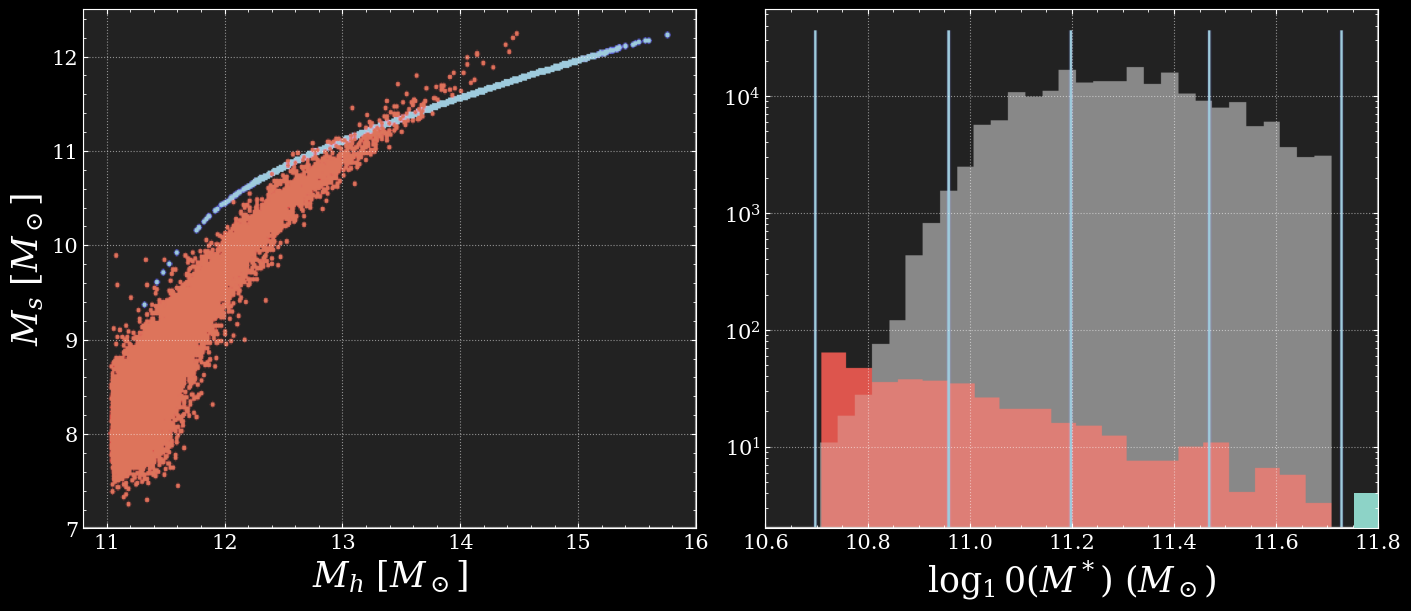

In [ ]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, axs = Plots.Moser2021().Fig3()

In [ ]:
masses=np.loadtxt(f'{DATA_PATH}/Amodeo2021/mass_distrib.txt')
plt.hist(np.log10(masses), bins=70)
plt.yscale('log')

## Ried-Guachalla 2025

In [ ]:
thing = np.loadtxt(f'{DATA_PATH}/Schaan2021/catalog.txt').T

(array([17347., 30308., 41205., 51155., 56811., 60036., 59688., 58321.,
        56751., 54668., 49623., 44425., 40835., 35687., 30472., 25610.,
        21146., 17685., 14146., 11283.]),
 array([0.430001  , 0.44350095, 0.4570009 , 0.47050085, 0.4840008 ,
        0.49750075, 0.5110007 , 0.52450065, 0.5380006 , 0.55150055,
        0.5650005 , 0.57850045, 0.5920004 , 0.60550035, 0.6190003 ,
        0.63250025, 0.6460002 , 0.65950015, 0.6730001 , 0.68650005,
        0.7       ]),
 <BarContainer object of 20 artists>)

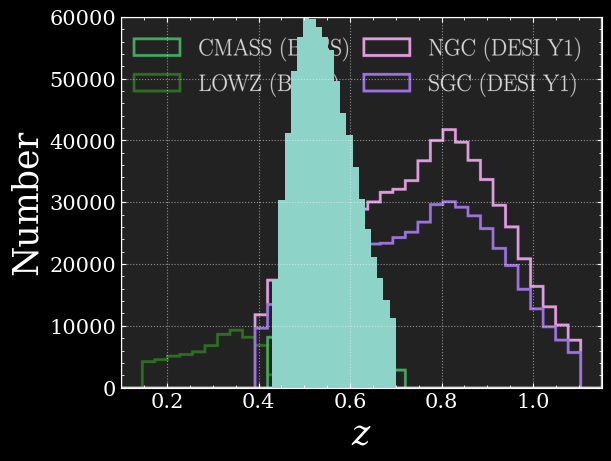

In [17]:
importlib.reload(Plots); importlib.reload(TargetData)

fig, ax = Plots.RiedGuachalla2025().Fig20()

ax.hist(thing[2], bins=20)

## Yuan 2023

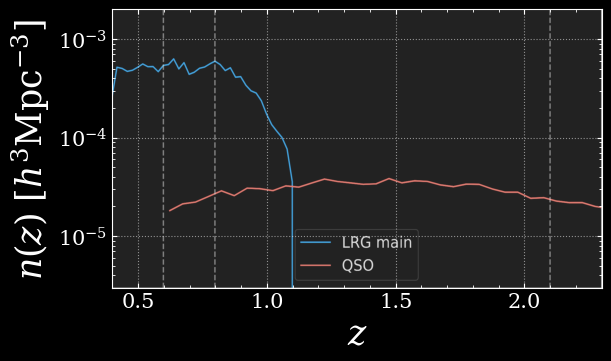

In [132]:
import Plots
importlib.reload(Plots)

fig, ax = Plots.Yuan2023().Fig1()

## Schaan 2021

paper Ngal: 311309, sum of N: 777202.00, int of dNdz 770423


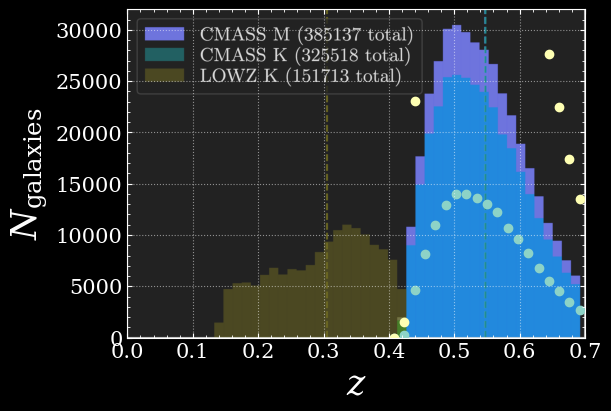

In [189]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, ax = Plots.Schaan2021().Fig2()

S21 = TargetData.Schaan2021(sample='cmass')
S21.make_zdist(zNum=20)
ax.scatter(S21.z, S21.N_z/5, label='cmass')

print(f'paper Ngal: {S21.Ngal}, sum of N: {np.sum(S21.N_z):.2f}, int of dNdz {np.trapezoid(S21.dNdz, S21.z):.0f}')

S21 = TargetData.Schaan2021(sample='lowz')
S21.make_zdist(zNum=20)
ax.scatter(S21.z, S21.N_z, label='lowz')

plt.show()

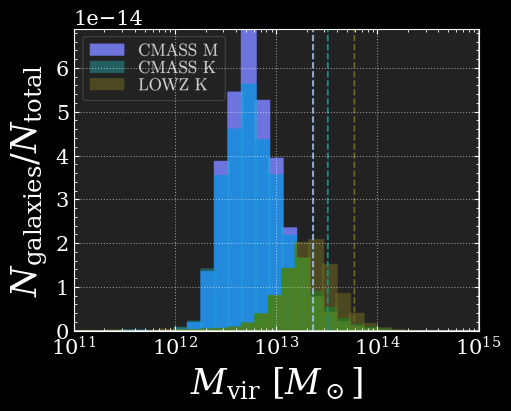

In [28]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, ax = Plots.Schaan2021().Fig3()

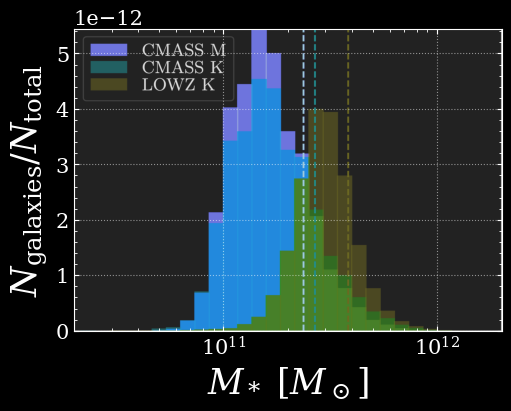

In [29]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, ax = Plots.Schaan2021().Fig31()

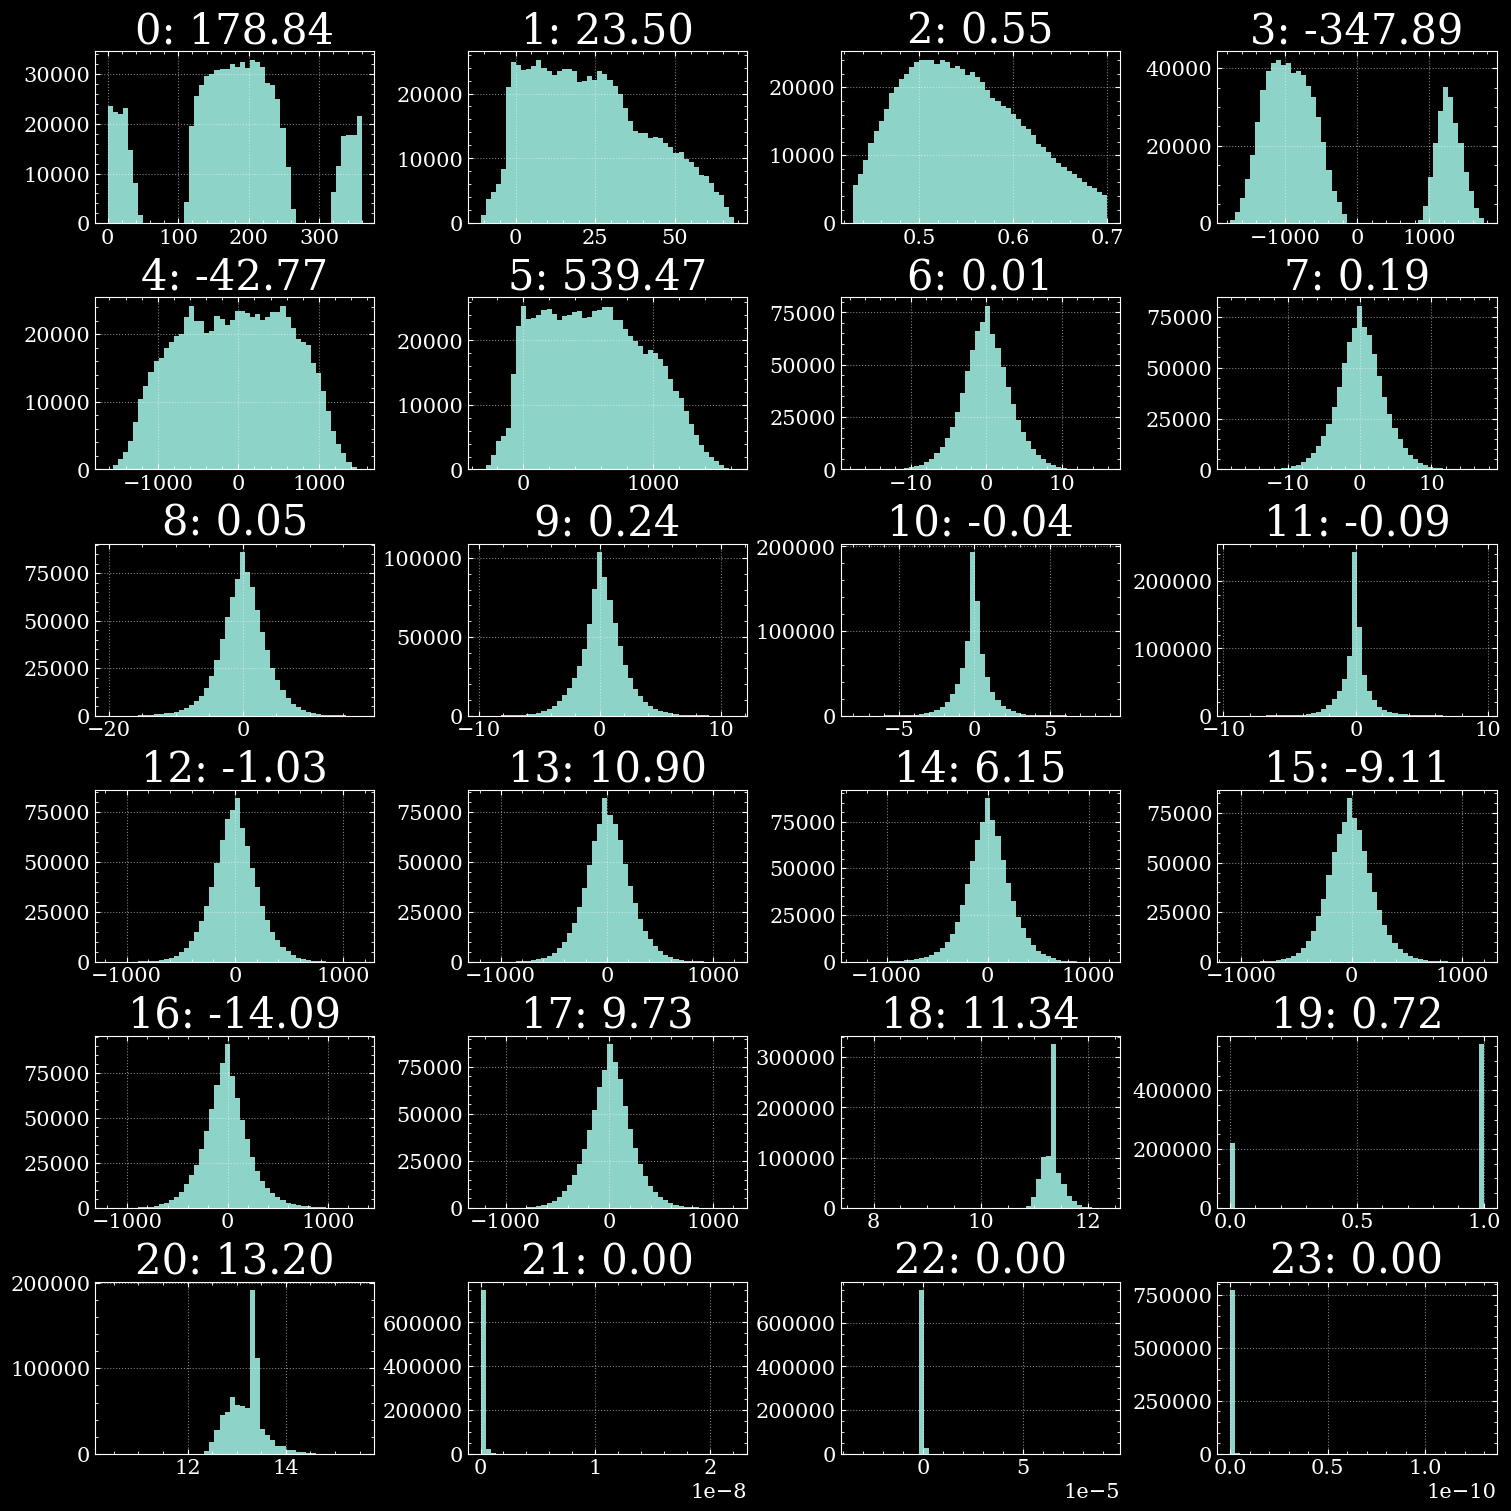

In [49]:
fig, axs = plt.subplots(6, 4, figsize=(15, 15), layout='constrained')
axs=axs.flatten()
for i, ax in zip(range(24), axs):
    if i in [18, 20]:
        ax.hist(np.log10(thing[:,i]), bins=50)
        ax.set_title(f'{i}: {np.mean(np.log10(thing[:,i])):.2f}')
    else: 
        ax.hist(thing[:,i], bins=50)
        ax.set_title(f'{i}: {np.mean(thing[:,i]):.2f}')